In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Solo cargar las 2 columnas que necesitamos (ahorra ~80% de RAM)
df_playtime = pd.read_csv('data/reviews.csv', usecols=['appid', 'author_playtime_at_review'])

print(f"Reviews cargadas: {len(df_playtime):,}")
print(f"Nulos en playtime: {df_playtime['author_playtime_at_review'].isna().sum():,}")

# Eliminar nulos
df_playtime = df_playtime.dropna()

# Convertir minutos a horas
df_playtime['playtime_hours'] = df_playtime['author_playtime_at_review'] / 60

# Calcular promedio por juego
playtime_avg = df_playtime.groupby('appid')['playtime_hours'].agg(
    playtime_mean='mean',
    playtime_median='median',
    n_reviews='count'
).reset_index()

print(f"\nJuegos con datos de playtime: {len(playtime_avg):,}")
print(playtime_avg.describe())

Reviews cargadas: 1,048,148
Nulos en playtime: 178,857

Juegos con datos de playtime: 86,222
              appid  playtime_mean  playtime_median     n_reviews
count  8.622200e+04   86222.000000     86222.000000  86222.000000
mean   1.677067e+06      13.580031         9.272274     10.082009
std    9.840018e+05     128.286064       117.768641     19.586199
min    4.000000e+02       0.016667         0.016667      1.000000
25%    8.336625e+05       0.816667         0.600000      1.000000
50%    1.565205e+06       2.383333         1.750000      3.000000
75%    2.434472e+06       7.027778         5.233333      9.000000
max    3.959570e+06   20697.650000     20697.650000    100.000000


Juegos con >= 5 reviews: 32,033


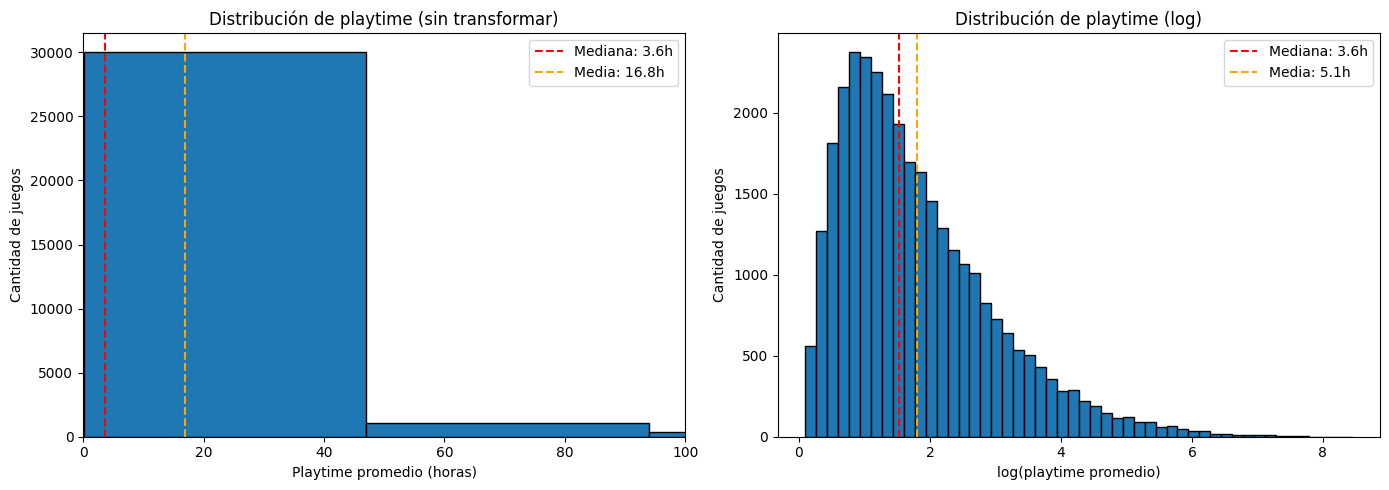

count    32033.000000
mean        16.843445
std         75.888687
min          0.100000
25%          1.508333
50%          3.601961
75%         10.379487
max       4691.181650
Name: playtime_mean, dtype: float64


In [21]:
# Filtrar juegos con al menos 5 reviews (promedio más confiable)
playtime_filtrado = playtime_avg[playtime_avg['n_reviews'] >= 5].copy()
print(f"Juegos con >= 5 reviews: {len(playtime_filtrado):,}")

# Calcular estadísticas
media = playtime_filtrado['playtime_mean'].mean()
mediana = playtime_filtrado['playtime_mean'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sin transformar
axes[0].hist(playtime_filtrado['playtime_mean'], bins=100, edgecolor='black')
axes[0].axvline(mediana, color='red', linestyle='--', label=f'Mediana: {mediana:.1f}h')
axes[0].axvline(media, color='orange', linestyle='--', label=f'Media: {media:.1f}h')
axes[0].set_xlim(0, 100)
axes[0].set_xlabel('Playtime promedio (horas)')
axes[0].set_ylabel('Cantidad de juegos')
axes[0].set_title('Distribución de playtime (sin transformar)')
axes[0].legend()

# Con log
# Con log
log_media = np.log1p(playtime_filtrado['playtime_mean']).mean()
log_mediana = np.log1p(playtime_filtrado['playtime_mean']).median()

# Invertir para mostrar en horas reales
media_real = np.expm1(log_media)
mediana_real = np.expm1(log_mediana)

axes[1].hist(np.log1p(playtime_filtrado['playtime_mean']), bins=50, edgecolor='black')
axes[1].axvline(log_mediana, color='red', linestyle='--', label=f'Mediana: {mediana_real:.1f}h')
axes[1].axvline(log_media, color='orange', linestyle='--', label=f'Media: {media_real:.1f}h')
axes[1].set_xlabel('log(playtime promedio)')
axes[1].set_ylabel('Cantidad de juegos')
axes[1].set_title('Distribución de playtime (log)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(playtime_filtrado['playtime_mean'].describe())

In [9]:
# Cargar datos necesarios
df_apps = pd.read_csv('data-cleaned/applications.csv', low_memory=False)
df_application_genres = pd.read_csv('data/application_genres.csv')
df_application_platforms = pd.read_csv('data/application_platforms.csv')

# Merge playtime con applications
df_model = playtime_filtrado.merge(df_apps, on='appid', how='inner')
print(f"Juegos tras merge: {len(df_model):,}")

# Construir features
import re

def count_langs(x):
    if pd.isna(x): return 0
    clean = re.sub(r'<[^>]+>', '', str(x))
    clean = re.sub(r'\*', '', clean)
    return len([l for l in clean.split(',') if l.strip()])

df_model['n_languages'] = df_model['supported_languages'].apply(count_langs)
df_model['price_usd'] = df_model['mat_final_price'] / 100
df_model['release_date'] = pd.to_datetime(df_model['release_date'], errors='coerce')
df_model['release_year'] = df_model['release_date'].dt.year

# Merge con géneros y plataformas
n_genres = df_application_genres.groupby('appid').size().rename('n_genres')
n_platforms = df_application_platforms.groupby('appid').size().rename('n_platforms')
df_model = df_model.merge(n_genres, on='appid', how='left')
df_model = df_model.merge(n_platforms, on='appid', how='left')

# Target: log del playtime promedio
df_model['log_playtime'] = np.log1p(df_model['playtime_mean'])
# Corregir: filtrar outliers de precio
df_model = df_model[df_model['price_usd'] <= 60].copy()

# Quitar is_free (toda la columna es 0, sin varianza)
features = ['price_usd', 'mat_achievement_count', 'n_genres', 
            'n_platforms', 'n_languages', 'release_year']

modelo_df = df_model[features + ['log_playtime']].dropna()
print(f"Filas para modelar: {len(modelo_df):,}")
print(modelo_df.describe())

Juegos tras merge: 31,838
Filas para modelar: 18,926
          price_usd  mat_achievement_count      n_genres   n_platforms  \
count  18926.000000           18926.000000  18926.000000  18926.000000   
mean      10.503981              36.066892      2.852795      1.438392   
std       10.295474             154.323925      1.296146      0.733557   
min        0.490000               0.000000      1.000000      1.000000   
25%        2.990000              11.000000      2.000000      1.000000   
50%        6.990000              21.000000      3.000000      1.000000   
75%       14.990000              38.000000      4.000000      2.000000   
max       60.000000            5000.000000     10.000000      3.000000   

        n_languages  release_year  log_playtime  
count  18926.000000  18926.000000  18926.000000  
mean       7.292930   2020.671457      1.925129  
std       14.215499      3.305007      1.125595  
min        0.000000   2006.000000      0.095310  
25%        1.000000   2018.000

## Regresion

In [10]:
from sklearn.model_selection import train_test_split

X = modelo_df[features]
y = modelo_df['log_playtime']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (13248, 6)
X_test:  (5678, 6)


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

print("=== Regresión Lineal ===")
print(f"R² test: {r2_score(y_test, y_pred_lr):.4f}")
print(f"\nCoeficientes:")
coefs = pd.DataFrame({'Feature': features, 'Coeficiente': modelo_lr.coef_})
print(coefs)
print(f"Intercepto: {modelo_lr.intercept_:.4f}")

=== Regresión Lineal ===
R² test: 0.3097

Coeficientes:
                 Feature  Coeficiente
0              price_usd     0.059703
1  mat_achievement_count     0.000616
2               n_genres     0.015630
3            n_platforms     0.118170
4            n_languages     0.000145
5           release_year    -0.029698
Intercepto: 61.0721


In [12]:
residuos = y_test.values[:10] - y_pred_lr[:10]
df_residuos = pd.DataFrame({
    'y_real': np.round(y_test.values[:10], 3),
    'y_prediccion': np.round(y_pred_lr[:10], 3),
    'residuo': np.round(residuos, 3)
})
print(df_residuos)

   y_real  y_prediccion  residuo
0   2.109         2.057    0.053
1   2.645         1.957    0.688
2   1.147         1.344   -0.197
3   0.761         1.409   -0.647
4   0.550         1.416   -0.866
5   1.673         2.173   -0.500
6   4.145         3.598    0.548
7   1.733         2.043   -0.310
8   3.020         2.997    0.024
9   4.588         3.610    0.978


In [13]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Features originales: {X_train.shape[1]}")
print(f"Features polinomiales: {X_train_poly.shape[1]}")

modelo_lr_poly = LinearRegression()
modelo_lr_poly.fit(X_train_poly, y_train)
y_pred_lr_poly = modelo_lr_poly.predict(X_test_poly)

Features originales: 6
Features polinomiales: 28


In [14]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

In [15]:
modelo_rf_poly = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_poly.fit(X_train_poly, y_train)
y_pred_rf_poly = modelo_rf_poly.predict(X_test_poly)

In [16]:
y_pred_lr_train = modelo_lr.predict(X_train)
y_pred_lr_poly_train = modelo_lr_poly.predict(poly.transform(X_train))
y_pred_rf_train = modelo_rf.predict(X_train)
y_pred_rf_poly_train = modelo_rf_poly.predict(poly.transform(X_train))

def calcular_metricas(y_true, y_pred, y_true_train, y_pred_train):
    return {
        "R² train": r2_score(y_true_train, y_pred_train),
        "R² test": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

resumen = pd.DataFrame({
    "Reg. Lineal (Original)": calcular_metricas(y_test, y_pred_lr, y_train, y_pred_lr_train),
    "Reg. Lineal (Polinomial)": calcular_metricas(y_test, y_pred_lr_poly, y_train, y_pred_lr_poly_train),
    "Random Forest (Original)": calcular_metricas(y_test, y_pred_rf, y_train, y_pred_rf_train),
    "Random Forest (Polinomial)": calcular_metricas(y_test, y_pred_rf_poly, y_train, y_pred_rf_poly_train),
}).T

print(resumen)

                            R² train   R² test      RMSE       MAE
Reg. Lineal (Original)      0.309555  0.309659  0.927729  0.702056
Reg. Lineal (Polinomial)    0.391287  0.382861  0.877164  0.654867
Random Forest (Original)    0.906858  0.383160  0.876951  0.652090
Random Forest (Polinomial)  0.908568  0.395300  0.868279  0.647256


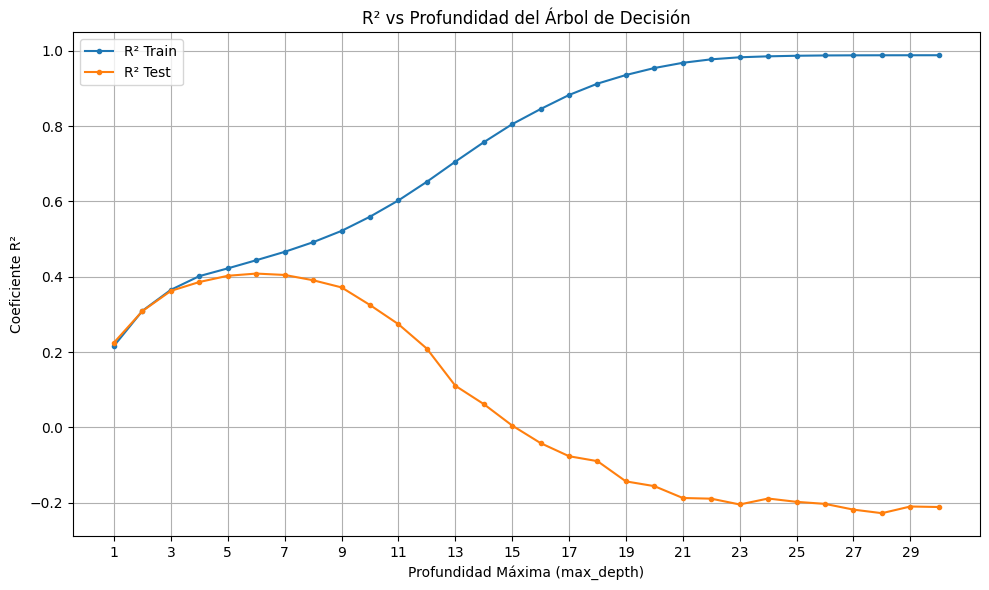

In [17]:
from sklearn.tree import DecisionTreeRegressor

res = []
for md in range(1, 31):
    tree = DecisionTreeRegressor(max_depth=md, random_state=42)
    tree.fit(X_train, y_train)
    res.append({
        'profundidad': md,
        'r2_train': tree.score(X_train, y_train),
        'r2_test': tree.score(X_test, y_test)
    })

df_depth = pd.DataFrame(res)

plt.figure(figsize=(10, 6))
plt.plot(df_depth['profundidad'], df_depth['r2_train'], label='R² Train', marker='o', markersize=3)
plt.plot(df_depth['profundidad'], df_depth['r2_test'], label='R² Test', marker='o', markersize=3)
plt.title('R² vs Profundidad del Árbol de Decisión')
plt.xlabel('Profundidad Máxima (max_depth)')
plt.ylabel('Coeficiente R²')
plt.xticks(range(1, 31, 2))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

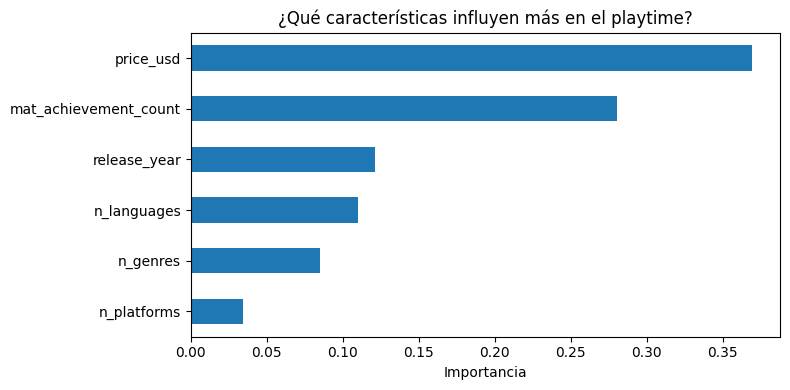

In [18]:
importancia = pd.Series(modelo_rf.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 4))
importancia.plot.barh()
plt.xlabel('Importancia')
plt.title('¿Qué características influyen más en el playtime?')
plt.tight_layout()
plt.show()

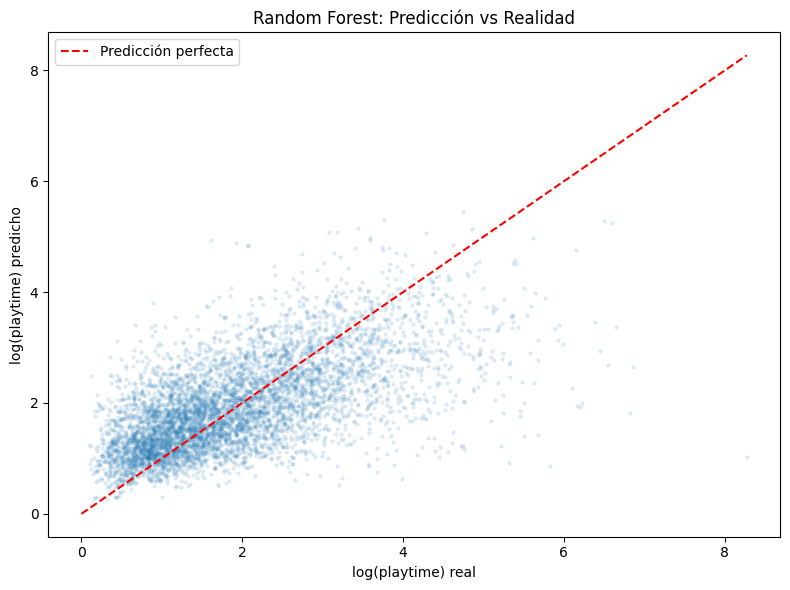

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.1, s=5)
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Predicción perfecta')
plt.xlabel('log(playtime) real')
plt.ylabel('log(playtime) predicho')
plt.title('Random Forest: Predicción vs Realidad')
plt.legend()
plt.tight_layout()
plt.show()